<a href="https://colab.research.google.com/github/farkhad-gazizov/educational/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BA_%D0%BB%D0%B5%D0%BA%D1%86%D0%B8%D0%B8_%22%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D1%8B%22_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание к лекции "Классы"

**Задание 1**

Напишите функцию, которая возвращает название валюты (поле ‘Name’) с максимальным значением курса с помощью сервиса https://www.cbr-xml-daily.ru/daily_json.js

**Решение без использования класса:**

In [ ]:
import requests

In [ ]:
def get_currency_with_max_rate():
    r = requests.get('https://www.cbr-xml-daily.ru/daily_json.js')
    data = r.json()['Valute']

    # Находим словарь валюты с максимальным курсом.
    # key=lambda x: x['Value'] — сравниваем по полю 'Value'
    max_currency_name = max(data.values(), key= lambda x: x['Value'])['Name']

    return f'Название валюты с максимальным значением курса: {max_currency_name}'

In [ ]:
get_currency_with_max_rate()

'Название валюты с максимальным значением курса: Бахрейнский динар'

**Решение с использованием импортированного из файла exchange.py класса Rate:**

In [ ]:
from exchange import Rate

In [ ]:
def get_currency_with_max_rate(rates):
    data = rates.exchange_rates()

    # Находим словарь валюты с максимальным курсом.
    # key=lambda x: x['Value'] — сравниваем по полю 'Value'
    max_currency_name = max(data.values(), key= lambda x: x['Value'])['Name']

    return f'Название валюты с максимальным значением курса: {max_currency_name}'

In [ ]:
rate = Rate()
get_currency_with_max_rate(rate)

'Название валюты с максимальным значением курса: Бахрейнский динар'

**Задание 2**

Добавьте в класс `Rate` параметр `diff` (со значениями `True` или `False`), который в случае значения `True` в методах курсов валют (eur, usd итд) будет возвращать не курс валюты, а изменение по сравнению в прошлым значением. Считайте, `self.diff` будет принимать значение `True` только при возврате значения курса. При отображении всей информации о валюте он не используется.

In [ ]:
class Rate:
    # по условию задачи добавлен параметр diff и атрибут self.diff
    def __init__(self, format='value', diff=False):
        self.format = format
        self.diff = diff

    def exchange_rates(self):
        """
        Возвращает ответ сервиса с информацией о валютах в виде:

        {
            'AMD': {
                'CharCode': 'AMD',
                'ID': 'R01060',
                'Name': 'Армянских драмов',
                'Nominal': 100,
                'NumCode': '051',
                'Previous': 14.103,
                'Value': 14.0879
                },
            ...
        }
        """
        r = requests.get('https://www.cbr-xml-daily.ru/daily_json.js')
        return r.json()['Valute']

    def make_format(self, currency):
        """
        Возвращает информацию о валюте currency в двух вариантах:
        - полная информация о валюте при self.format = 'full':
        Rate('full').make_format('EUR')
        {
            'CharCode': 'EUR',
            'ID': 'R01239',
            'Name': 'Евро',
            'Nominal': 1,
            'NumCode': '978',
            'Previous': 79.6765,
            'Value': 79.4966
        }

        Rate('value').make_format('EUR')
        79.4966
        """
        response = self.exchange_rates()

        if currency in response:
            # при отображении полной информации self.diff не используется
            if self.format == 'full':
                return response[currency]

            if self.format == 'value':
                # если self.diff будет True, то метод вернет разницу курсов...
                if self.diff:
                    return response[currency]['Value'] - response[currency]['Previous']
                # а в обратном случае только текущий курс
                return response[currency]['Value']

        return 'Error'

    def eur(self):
        """Возвращает курс евро на сегодня в формате self.format"""
        return self.make_format('EUR')

    def usd(self):
        """Возвращает курс доллара на сегодня в формате self.format"""
        return self.make_format('USD')


In [ ]:
# демонстрация работы без указания значения self.diff (false по умолчанию)
# отображение текущего курса
rate1 = Rate()
rate1.eur()

88.549

In [ ]:
# демонстрация работы с указанием значения self.diff = True
# отображение разницы текущего и предыдущего курса
rate2 = Rate('value', diff=True)
rate2.eur()

0.6593000000000018

In [ ]:
# демонстрация работы при отображении полной информации
# self.diff не используется
rate3 = Rate('full')
rate3.eur()

{'ID': 'R01239',
 'NumCode': '978',
 'CharCode': 'EUR',
 'Nominal': 1,
 'Name': 'Евро',
 'Value': 88.549,
 'Previous': 87.8897}

**Задание 3**

Напишите класс `Designer`, который учитывает количество международных премий. Подсказки в коде занятия (“Ноутбук к лекциям «Понятие класса» + презентация”, zip-файл “Используемый ноутбук к лекциям «Понятие класса»).

Комментарий по классу `Designer` такой:
Напишите класс `Designer`, который учитывает количество международных премий для дизайнеров (из презентации: “Повышение на 1 грейд за каждые 7 баллов. Получение международной премии – это +2 балла”). Считайте, что при выходе на работу сотрудник уже имеет две премии и их количество не меняется со стажем (конечно если хотите это можно вручную менять).

Класс `Designer` пишется по аналогии с классом `Developer` из материалов занятия.

In [ ]:
class Employee:
    def __init__(self, name, seniority):
        self.name = name
        self.seniority = seniority

        self.grade = 1

    def grade_up(self):
        """Повышает уровень сотрудника"""
        self.grade += 1

    def publish_grade(self):
        """Публикация результатов аккредитации сотрудников"""
        print(self.name, self.grade)

    def check_if_it_is_time_for_upgrade(self):
        pass

In [ ]:
class Designer(Employee):
    def __init__(self, name, seniority, awards=2):
        super().__init__(name, seniority + awards * 2)
        self.awards = awards

    def check_if_it_is_time_for_upgrade(self):
        # для каждой аккредитации увеличиваем счетчик на 1
        # пока считаем, что все разработчики проходят аккредитацию
        self.seniority += 1

        # условие повышения сотрудника
        if self.seniority % 7 == 0:
            self.grade_up()

        # публикация результатов
        return self.publish_grade()

    def add_award(self):
        '''
        метод для ручного добавления премии, каждая из которых добавляет
        2 балла к seniority
        '''
        self.awards += 1
        self.seniority += 2

In [ ]:
# проверка работы системы повышения сотрудников
# дизайнер Айгуль только что устроена на работу и у нее есть 2 премии
# выводим количество ее баллов в начале работы
designer = Designer('Айгуль', 0)
print(designer.seniority)

4


In [ ]:
# проверяем, как растет grade при итеративном увеличении seniority (количества баллов)
for i in range(20):
    designer.check_if_it_is_time_for_upgrade()

Айгуль 1
Айгуль 1
Айгуль 2
Айгуль 2
Айгуль 2
Айгуль 2
Айгуль 2
Айгуль 2
Айгуль 2
Айгуль 3
Айгуль 3
Айгуль 3
Айгуль 3
Айгуль 3
Айгуль 3
Айгуль 3
Айгуль 4
Айгуль 4
Айгуль 4
Айгуль 4


In [ ]:
# добавляем сотруднику еще одну премию
# и выводим количество баллов и премий после добавления премии
designer.add_award()
print(designer.seniority)
print(designer.awards)

26
3


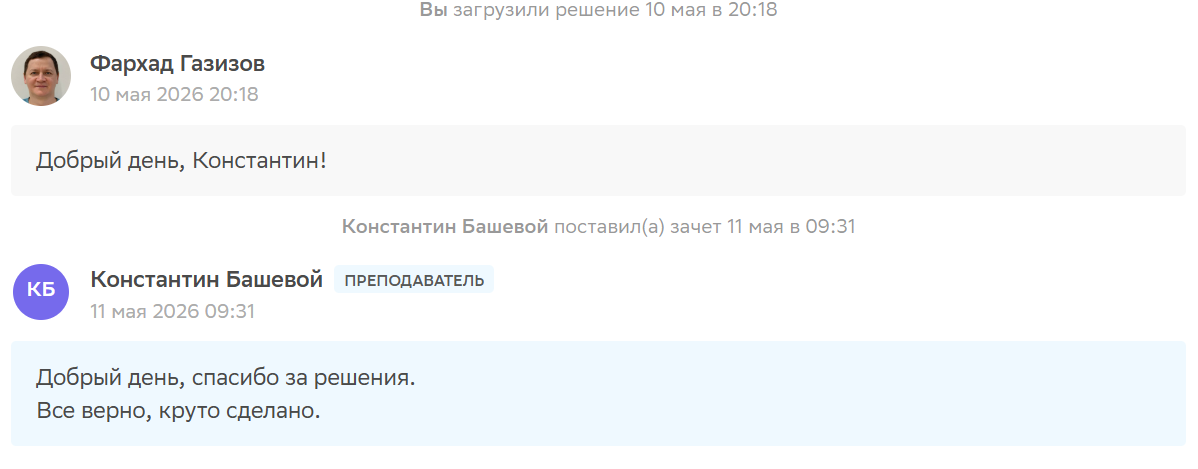